## Import Library

Tahap awal notebook ini adalah mengimpor library Python yang dibutuhkan. Library yang digunakan dibatasi pada kebutuhan pemrosesan data, perhitungan numerik, serta evaluasi model.

- **NumPy** digunakan untuk operasi numerik dan manipulasi array.
- **Pandas** digunakan untuk membaca dan memanipulasi dataset dalam bentuk tabel.
- **random** digunakan untuk menghasilkan nilai acak pada algoritma genetika.
- **sklearn.metrics** digunakan untuk menghitung metrik evaluasi seperti accuracy, precision, recall, F1-score, dan confusion matrix.

Import library dilakukan di awal agar seluruh fungsi dan kelas dapat digunakan pada tahap-tahap selanjutnya.


In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

## Load Dataset

Dataset yang digunakan adalah *Car Evaluation Dataset* yang disimpan dalam format CSV. Dataset ini berisi beberapa atribut kategorikal seperti harga, jumlah pintu, kapasitas penumpang, dan tingkat keamanan mobil, serta satu kolom target yaitu `class`.

Dataset dibaca menggunakan `pandas.read_csv()` dan disimpan dalam sebuah DataFrame agar mudah diproses lebih lanjut.


In [138]:
df = pd.read_csv("car_evaluation.csv")

In [139]:
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [140]:
df['class'] = df['class'].replace({
    'good': 'acc',
    'vgood': 'acc'
})

## Exploratory Data Analysis (EDA)

Tahap eksplorasi data dilakukan untuk memahami struktur dataset, antara lain:
- Jumlah baris dan kolom
- Nama dan tipe setiap atribut
- Distribusi nilai pada kolom target `class`

EDA membantu memastikan bahwa dataset bersifat kategorikal dan cocok untuk digunakan pada algoritma Naive Bayes kategorikal.


In [141]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [142]:
print(df['class'].value_counts())

class
unacc    1209
acc       518
Name: count, dtype: int64


In [143]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [144]:
df.duplicated().sum()

0

In [145]:
df.dtypes

buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
class       object
dtype: object

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [147]:
df.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1727,1727,1727,1727,1727,1727,1727
unique,4,4,4,3,3,3,2
top,high,high,3,4,med,med,unacc
freq,432,432,432,576,576,576,1209


In [148]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


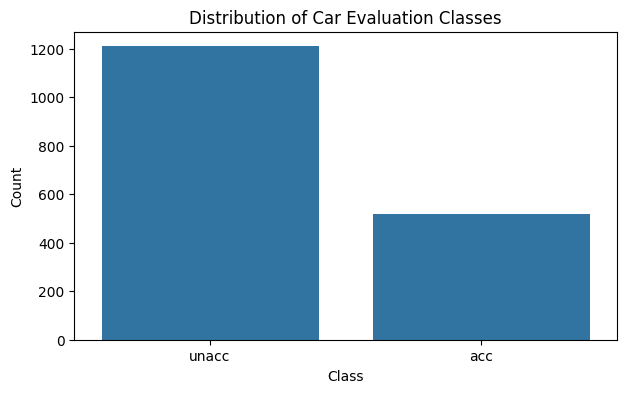

In [149]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='class')
plt.title("Distribution of Car Evaluation Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

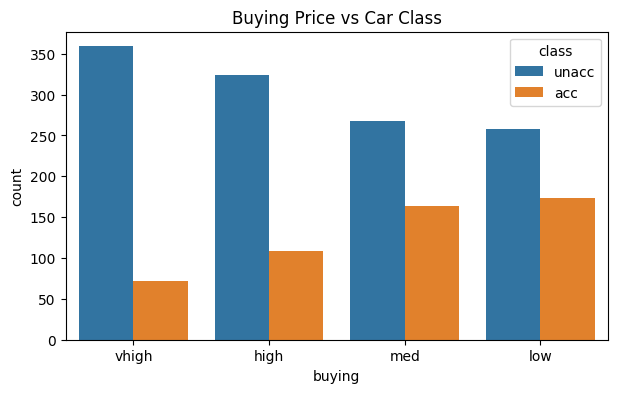

In [150]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='buying', hue='class')
plt.title("Buying Price vs Car Class")
plt.show()

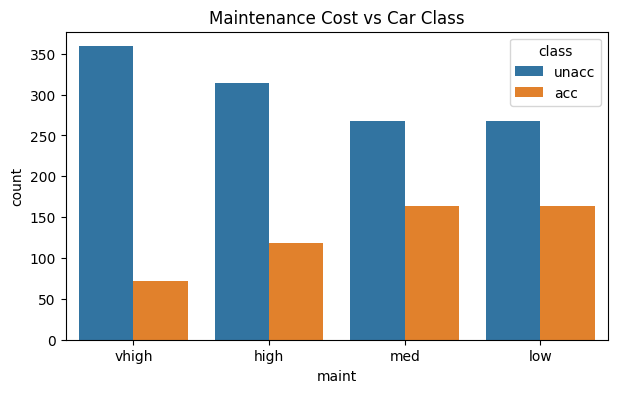

In [151]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='maint', hue='class')
plt.title("Maintenance Cost vs Car Class")
plt.show()

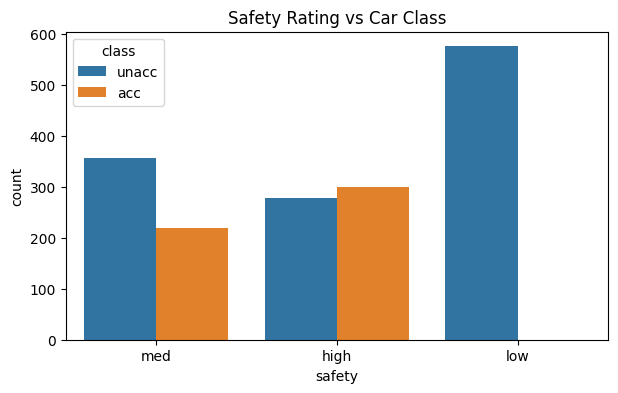

In [152]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='safety', hue='class')
plt.title("Safety Rating vs Car Class")
plt.show()

## Preprocessing Data

Karena seluruh atribut pada dataset bersifat kategorikal, maka diperlukan proses encoding untuk mengubah nilai kategori menjadi representasi numerik.

Proses encoding dilakukan secara manual tanpa menggunakan library `scikit-learn`, dengan tujuan:
- Memahami proses encoding secara konseptual
- Menghindari penggunaan library otomatis sesuai ketentuan tugas

Setiap nilai kategori pada tiap kolom dipetakan ke bilangan bulat unik, sehingga dataset dapat diproses oleh algoritma Naive Bayes.


In [153]:
def label_encode(df):
    mappings = {}
    df_encoded = df.copy()

    for col in df.columns:
        unique_vals = df[col].unique()
        mapping = {val: idx for idx, val in enumerate(unique_vals)}
        df_encoded[col] = df[col].map(mapping)
        mappings[col] = mapping

    return df_encoded, mappings

## Pemisahan Fitur dan Label

Setelah proses encoding selesai, dataset dipisahkan menjadi:
- **X (fitur)** → seluruh kolom selain `class`
- **y (label)** → kolom `class`

Pemisahan ini diperlukan agar model dapat dilatih menggunakan fitur dan dievaluasi berdasarkan label yang benar.


In [154]:
df_encoded, encoders = label_encode(df)

X = df_encoded.drop("class", axis=1).values
y = df_encoded["class"].values

# Pembagian Data Training dan Testing (Train-Test Split)

Data dibagi menjadi data training dan data testing menggunakan fungsi `train_test_split` yang diimplementasikan secara manual tanpa menggunakan parameter random seed.

## Tahapan Pembagian Data

Tahapan utama dalam proses pembagian data ini meliputi:

1. **Membuat indeks data** berdasarkan jumlah sampel yang tersedia
2. **Mengacak urutan indeks** secara acak menggunakan fungsi `np.random.shuffle`
3. **Menentukan batas pemisahan** data berdasarkan proporsi `test_size`
4. **Memisahkan data** menjadi subset training dan testing berdasarkan indeks yang telah diacak
5. **Mengembalikan empat subset** data, yaitu `X_train`, `X_test`, `y_train`, dan `y_test`


## Karakteristik Implementasi

### Non-Deterministik

Karena tidak menggunakan random seed, proses pembagian data ini bersifat **non-deterministik**, sehingga komposisi data training dan testing dapat berbeda pada setiap eksekusi program.

**Keuntungan:**
- Memungkinkan eksplorasi berbagai kombinasi data split
- Berguna untuk menguji robustness model terhadap variasi data

**Kekurangan:**
- Hasil tidak dapat direproduksi dengan tepat
- Dapat menyebabkan variasi hasil evaluasi model antar percobaan
- Menyulitkan debugging dan perbandingan hasil



In [155]:
def train_test_split(X, y, test_size=0.2):
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    split = int(len(X) * (1 - test_size))
    train_idx, test_idx = indices[:split], indices[split:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X_train, X_test, y_train, y_test = train_test_split(X, y)


# Implementasi Naive Bayes Classifier (From Scratch)

Pada bagian ini diimplementasikan algoritma **Naive Bayes Classifier** secara manual tanpa menggunakan library `scikit-learn`. Model ini dirancang untuk menangani **fitur kategorikal** dan mendukung **Laplace Smoothing** melalui parameter `alpha`. Implementasi from-scratch ini bertujuan untuk memberikan pemahaman menyeluruh mengenai cara kerja Naive Bayes, mulai dari perhitungan probabilitas hingga proses prediksi.

---

## Inisialisasi Model

Model Naive Bayes diinisialisasi melalui konstruktor kelas dengan parameter `alpha`. Parameter `alpha` digunakan sebagai **Laplace Smoothing**, yaitu teknik untuk menghindari probabilitas nol ketika suatu nilai fitur tidak muncul pada data training. Nilai `alpha` ini nantinya dioptimasi menggunakan Algoritma Genetika.

---

## Proses Training Model (`fit`)

Fungsi `fit()` digunakan untuk melatih model berdasarkan data training (`X`) dan label (`y`).

### Menentukan Kelas Unik

Langkah pertama adalah mengambil seluruh kelas unik dari label target. Informasi ini diperlukan untuk:

- Menghitung probabilitas prior setiap kelas
- Menentukan kelas yang akan dibandingkan saat proses prediksi

---

### Inisialisasi Struktur Probabilitas

Dua struktur data utama digunakan:

- **Probabilitas prior (`class_prob`)** untuk menyimpan peluang setiap kelas
- **Probabilitas likelihood (`feature_prob`)** untuk menyimpan peluang setiap nilai fitur terhadap kelas tertentu

---

### Perhitungan Probabilitas Prior

Probabilitas prior dihitung sebagai perbandingan jumlah data pada suatu kelas terhadap total data training. Secara matematis:

$$P(C) = \frac{\text{Jumlah data pada kelas } C}{\text{Jumlah seluruh data}}$$

Probabilitas ini mencerminkan seberapa sering suatu kelas muncul dalam dataset.

---

### Perhitungan Probabilitas Likelihood

Untuk setiap kelas dan setiap fitur, dihitung probabilitas kemunculan nilai fitur tertentu pada kelas tersebut. Proses ini dilakukan dengan:

1. Mengambil nilai unik fitur
2. Menghitung frekuensi kemunculannya
3. Mengubah frekuensi menjadi probabilitas

---

### Laplace Smoothing

Untuk mencegah probabilitas bernilai nol, digunakan **Laplace Smoothing** dengan rumus:

$$P(x_i = v \mid C) = \frac{c + \alpha}{N + \alpha \cdot k}$$

**Keterangan:**

- $c$ : jumlah kemunculan nilai fitur
- $N$ : total data pada kelas
- $k$ : jumlah nilai unik fitur
- $\alpha$ : parameter smoothing

Laplace Smoothing memastikan semua probabilitas bernilai positif dan stabil.

---

### Penyimpanan Probabilitas

Probabilitas likelihood disimpan dalam struktur bertingkat dengan format:

```python
feature_prob[kelas][indeks_fitur][nilai_fitur]
```

Struktur ini memudahkan pengambilan probabilitas saat proses prediksi.

---

## Proses Prediksi (`predict`)

Fungsi `predict()` digunakan untuk menentukan kelas dari data baru berdasarkan model yang telah dilatih.

---

### Perhitungan Posterior Probability

Untuk setiap data uji dan setiap kelas, dihitung **posterior probability** menggunakan prinsip Naive Bayes:

$$P(C \mid x) \propto P(C) \prod P(x_i \mid C)$$

Agar perhitungan lebih stabil secara numerik, digunakan **log-probability**, sehingga perkalian diubah menjadi penjumlahan.

---

### Penanganan Nilai Fitur Baru

Jika suatu nilai fitur tidak ditemukan pada data training, maka digunakan nilai probabilitas fallback berbasis Laplace Smoothing. Hal ini mencegah log-probability bernilai tak hingga.

---

### Penentuan Kelas

Kelas dengan nilai posterior tertinggi dipilih sebagai hasil prediksi. Pendekatan ini dikenal sebagai **Maximum A Posteriori (MAP)**.

---

## Output Prediksi

Hasil prediksi dikembalikan dalam bentuk array NumPy yang berisi label kelas untuk setiap data uji.

---


In [156]:
class NaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.class_prob = {}
        self.feature_prob = {}

        for cls in self.classes:
            X_cls = X[y == cls]
            self.class_prob[cls] = len(X_cls) / len(X)

            self.feature_prob[cls] = []
            for i in range(X.shape[1]):
                values, counts = np.unique(X_cls[:, i], return_counts=True)
                total = sum(counts)
                probs = {}

                for v, c in zip(values, counts):
                    probs[v] = (c + self.alpha) / (total + self.alpha * len(values))

                self.feature_prob[cls].append(probs)

    def predict(self, X):
        predictions = []

        for x in X:
            posteriors = {}

            for cls in self.classes:
                posterior = np.log(self.class_prob[cls])

                for i, val in enumerate(x):
                    probs = self.feature_prob[cls][i]
                    posterior += np.log(probs.get(val, self.alpha / (self.alpha + 1)))

                posteriors[cls] = posterior

            predictions.append(max(posteriors, key=posteriors.get))

        return np.array(predictions)


## Optimasi Hyperparameter dengan Algoritma Genetika

Setelah membangun model Naive Bayes, langkah selanjutnya adalah menentukan nilai hyperparameter alpha (Laplace Smoothing) yang paling optimal. Daripada menebak-nebak angka secara manual, digunakan pendekatan Algoritma Genetika dengan membangun kelas khusus bernama `GeneticsAlgorithmTuner`.

Kelas ini menerapkan algoritma genetika dengan tahapan sebagai berikut:

### Inisialisasi (init_pop)
Menciptakan populasi awal yang berisi sekumpulan nilai alpha acak (gen) sebagai kandidat solusi.

### Evaluasi Fitness (fitness)
Mengukur kebugaran setiap individu. Fitness didefinisikan sebagai akurasi model Naive Bayes pada data validasi saat menggunakan nilai alpha tertentu.

### Seleksi Alam (selection)
Memilih individu terbaik untuk menjadi induk generasi berikutnya menggunakan metode Tournament Selection, yaitu membandingkan dua individu secara acak dan memilih yang memiliki fitness lebih tinggi.

### Reproduksi (crossover)
Mengkombinasikan dua induk untuk menghasilkan individu baru dengan teknik rata-rata aritmatika dan rata-rata tertimbang.

### Mutasi (mutation)
Memberikan perubahan acak kecil pada sebagian individu untuk menjaga keragaman genetik dan mencegah konvergensi prematur.

### Siklus Utama (run)
Menjalankan seluruh proses evolusi selama sejumlah generasi tertentu dan menyimpan solusi terbaik (global best) berdasarkan nilai akurasi tertinggi yang diperoleh.


In [157]:
class GeneticsAlgorithmTuner: 
    def __init__(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        pop_size=10,
        generations=15,
        mutation_rate=0.01,
        alpha_min=0.0001,
        alpha_max=5.0
    ): 
        self.X_train = X_train
        self.y_train = y_train 
        self.X_val = X_val 
        self.y_val = y_val 
        self.pop_size = pop_size 
        self.generations = generations 
        self.mutation_rate = mutation_rate
        self.alpha_min = alpha_min
        self.alpha_max = alpha_max
        self.population = [] 

    
    # Inisialisasi Populasi
   
    def init_pop(self): 
        print(f"Initializing population with {self.pop_size} individuals")
        self.population = [
            random.uniform(self.alpha_min, self.alpha_max)
            for _ in range(self.pop_size)
        ]

    
    # Fitness Function
    
    def fitness(self, alpha): 
        model = NaiveBayes(alpha=alpha) 
        model.fit(self.X_train, self.y_train) 

        preds = model.predict(self.X_val)

        correct = sum(
            1 for p, t in zip(preds, self.y_val) if p == t
        )
        accuracy = correct / len(self.y_val)

        return accuracy
    
    
    # Tournament Selection
    
    def selection(self, scored_population): 
        parents = []
        for _ in range(self.pop_size): 
            contender_a = random.choice(scored_population)
            contender_b = random.choice(scored_population)

            if contender_a[1] > contender_b[1]: 
                parents.append(contender_a[0])
            else: 
                parents.append(contender_b[0])
        return parents
    
    
    # Crossover
    
    def crossover(self, parents): 
        offspring = [] 
        for i in range(0, self.pop_size, 2): 
            parent1 = parents[i]
            parent2 = parents[i+1] if i+1 < len(parents) else parents[0]

            child1 = (parent1 + parent2) / 2
            child2 = (parent1 * 0.7) + (parent2 * 0.3)

            offspring.extend([child1, child2])

        return offspring[:self.pop_size]
    
    
    # Mutation
    
    def mutation(self, population): 
        mutated_pop = [] 
        for alpha in population: 
            if random.random() < self.mutation_rate: 
                noise = random.uniform(-0.5, 0.5)
                new_alpha = abs(alpha + noise)

                # pastikan alpha tetap di range
                new_alpha = max(self.alpha_min, min(new_alpha, self.alpha_max))
                mutated_pop.append(new_alpha)
            else: 
                mutated_pop.append(alpha)
        return mutated_pop
    
    
    # Main GA Loop
    
    def run(self): 
        self.init_pop()

        global_best_alpha = None
        global_best_acc = -1

        for gen in range(self.generations): 
            scores = [] 
            for alpha in self.population: 
                acc = self.fitness(alpha) 
                scores.append((alpha, acc)) 

            # sort berdasarkan fitness
            scores.sort(key=lambda x: x[1], reverse=True)

            gen_best_alpha, gen_best_acc = scores[0]

            if gen_best_acc > global_best_acc:
                global_best_acc = gen_best_acc
                global_best_alpha = gen_best_alpha

            print(
                f"gen {gen+1}: best: "
                f"alpha = {gen_best_alpha:.4f}, "
                f"accuracy = {gen_best_acc*100:.2f}%"
            )

            parents = self.selection(scores)
            next_gen = self.crossover(parents)
            self.population = self.mutation(next_gen)

        print(
            f"\nGlobal Best -> "
            f"alpha = {global_best_alpha:.4f}, "
            f"accuracy = {global_best_acc*100:.2f}%"
        )

        return global_best_alpha


## Pemilihan Alpha Terbaik

Nilai alpha terbaik dipilih berdasarkan akurasi tertinggi yang diperoleh sepanjang seluruh generasi algoritma genetika (global best), bukan hanya dari generasi terakhir.

Pendekatan ini penting karena algoritma genetika tidak menjamin solusi terbaik muncul pada generasi akhir.


In [158]:
ga_tuner = GeneticsAlgorithmTuner(
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    pop_size=10,
    generations=15,
    mutation_rate=0.01
)

best_alpha = ga_tuner.run()

final_model = NaiveBayes(alpha=best_alpha)
final_model.fit(X_train, y_train)

final_preds = final_model.predict(X_test)

Initializing population with 10 individuals
gen 1: best: alpha = 0.0311, accuracy = 95.38%
gen 2: best: alpha = 0.7776, accuracy = 78.32%
gen 3: best: alpha = 0.8510, accuracy = 76.88%
gen 4: best: alpha = 0.8657, accuracy = 76.88%
gen 5: best: alpha = 0.8628, accuracy = 76.88%
gen 6: best: alpha = 0.8798, accuracy = 76.88%
gen 7: best: alpha = 0.8775, accuracy = 76.88%
gen 8: best: alpha = 0.8725, accuracy = 76.88%
gen 9: best: alpha = 0.8725, accuracy = 76.88%
gen 10: best: alpha = 0.8728, accuracy = 76.88%
gen 11: best: alpha = 0.8731, accuracy = 76.88%
gen 12: best: alpha = 0.8732, accuracy = 76.88%
gen 13: best: alpha = 0.8732, accuracy = 76.88%
gen 14: best: alpha = 0.8732, accuracy = 76.88%
gen 15: best: alpha = 0.8734, accuracy = 76.88%

Global Best -> alpha = 0.0311, accuracy = 95.38%


## Pelatihan Model Final

Setelah nilai alpha optimal diperoleh dari algoritma genetika, model Naive Bayes dilatih ulang menggunakan seluruh data training dengan nilai alpha terbaik tersebut.

Model inilah yang digunakan sebagai model final untuk evaluasi performa.


In [159]:
final_model = NaiveBayes(alpha=best_alpha)
final_model.fit(X_train, y_train)

final_preds = final_model.predict(X_test)

## Evaluasi Model Final

Model akhir dievaluasi menggunakan beberapa metrik evaluasi, antara lain:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Penggunaan beberapa metrik ini bertujuan untuk memberikan gambaran performa model yang lebih komprehensif, terutama pada dataset dengan distribusi kelas yang tidak seimbang.


Accuracy : 0.953757225433526
Precision: 0.9393939393939394
Recall   : 0.9029126213592233
F1-score : 0.9207920792079208


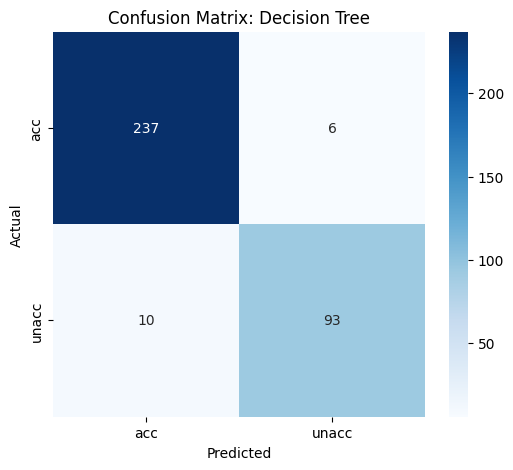

In [160]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="binary", pos_label=1)
recall = recall_score(y_test, y_pred, average="binary", pos_label=1)
f1 = f1_score(y_test, y_pred, average="binary", pos_label=1)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['acc', 'unacc'], 
            yticklabels=['acc', 'unacc'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Decision Tree')
plt.show()